# Search: Solving a Maze Using a Goal-based Agent

Student Name: [Add your name]

I have used the following AI tools: [list tools]

I understand that my submission needs to be my own work: [your initials]

## Learning Outcomes

* Formulate search problems using key components like initial state, actions, and goal state in a deterministic, fully observable environment.
* Implement and compare search algorithms including BFS, DFS, GBFS, A*, and IDS for planning paths through mazes.
* Analyze algorithm performance by measuring path cost, node expansions, depth, and memory usage across various maze types.
* Use visualization tools to represent maze paths and support debugging and analysis.

## Instructions

Total Points: Undergrads 100 + 5 bonus / Graduate students 110

Complete this notebook. Use the provided notebook cells and insert additional code and markdown cells as needed. Submit the notebook file and the completely rendered notebook with all outputs as a HTML file. 


## Introduction

In this exercise, we will implement the planning function for a type of goal-based agent called a __planning agent__. The planning function uses a map it is given to plan a path through the maze from the starting location $S$ to the goal location $G$. We will only focus on the planning function, so you do not need to implement an environment, just use the map to search for a path to solve the maze. 

Once the plan is made, the agent in a deterministic environment (i.e., the transition function is deterministic with the outcome of each state/action pair fixed and no randomness) can just follow the plan step-by-step and does not need to care about the percepts.
This is also called an **[open-loop system](https://en.wikipedia.org/wiki/Open-loop_controller).**
The execution phase is trivial and can be executed using a model-based reflex agent 
that ignores all percepts and just follows the plan. I will show you a short example, but you do not implement it in this exercise.

Given that the agent has a complete and correct map, the environment is **fully observable, discrete, deterministic, and known.** 
Remember:

* **Fully observable** means that the agent can see its state and what the available actions are. That means the **percepts contain the complete current state.**
Here, during planning, the agent always sees its x and y coordinates on the map and
also seeks when it has reached the goal state. 
* **Discrete** means that we have a **finite set of states.** The maze has a finite set 
of squares the agent can be in.
* **Deterministic** means that the **transition function contains no randomness.** An action in a state will always produce the same result. Going south from the start state always will lead to the same square.
* **Know** means that the agent **knows the complete transition function.** The 
agent has the map and therefore knows how its position changes when it walks in a direction.

Tree search algorithm implementations that you find online typically come from data structures courses and have a different aim than AI tree search. These algorithms assume that you already have a tree in memory. We are interested in dynamically creating a search tree with the aim of finding a good/the best path from the root note to the goal state. Follow the pseudo code presented in the text book (and replicated in the slides) closely. Ideally, we would like to search only a small part of the maze, i.e., create a search tree with as few nodes as possible. 

Several mazes for this exercise are stored as text files. We need to make sure that they are locally available.

In [1]:
# change directory to Google Drive for Google Colab
try:
    from google.colab import drive
    import os

    drive.mount('/content/drive')
    os.chdir('/content/drive/My Drive/Colab Notebooks/')
    print("Your working directory is now Google Drive: My Drive > Colab Notebooks")
except ImportError:
    pass

In [2]:
import urllib.request
import os

def download(file, base_url):
    if not os.path.exists(file):
        urllib.request.urlretrieve(base_url + file, file)

base_url = "https://raw.githubusercontent.com/mhahsler/Introduction_to_Artificial_Intelligence/refs/heads/master/Search/"
download("maze_helper.py", base_url)

mazes = ["small_maze.txt", "medium_maze.txt", "large_maze.txt", "L_maze.txt", "empty_maze.txt", "empty_maze_2.txt", "loops_maze.txt", "open_maze.txt", ]
for maze in mazes:
    download(maze, base_url)

Here is the small example maze:

In [3]:
with open("small_maze.txt", "r") as f:
    maze_str = f.read()
print(maze_str)

XXXXXXXXXXXXXXXXXXXXXX
X XX        X X      X
X    XXXXXX X XXXXXX X
XXXXXX     S  X      X
X    X XXXXXX XX XXXXX
X XXXX X         X   X
X        XXX XXX   X X
XXXXXXXXXX    XXXXXX X
XG         XX        X
XXXXXXXXXXXXXXXXXXXXXX



**Note:** If you get an error here that the file cannot be found, then you need to download it. See [HOWTO Work on Assignments.](https://github.com/mhahsler/CS7320-AI/blob/master/HOWTOs/working_on_assignments.md)

## Parsing and pretty printing the maze

The maze can also be displayed in color using code in the module [maze_helper.py](maze_helper.py). The code parses the string representing the maze and converts it into a `numpy` 2d array which you can use in your implementation. Position are represented as a 2-tuple of the form `(row, col)`. 

In [4]:
import maze_helper as mh

maze = mh.parse_maze(maze_str)

# look at a position in the maze by subsetting the 2d array
print("Position(0,0):", maze[0, 0])

# there is also a helper function called `look(maze, pos)` available
# which uses a 2-tuple for the position.
print("Position(8,1):", mh.look(maze, (8, 1)))

Position(0,0): X
Position(8,1): G


A helper function to visualize the maze is also available.

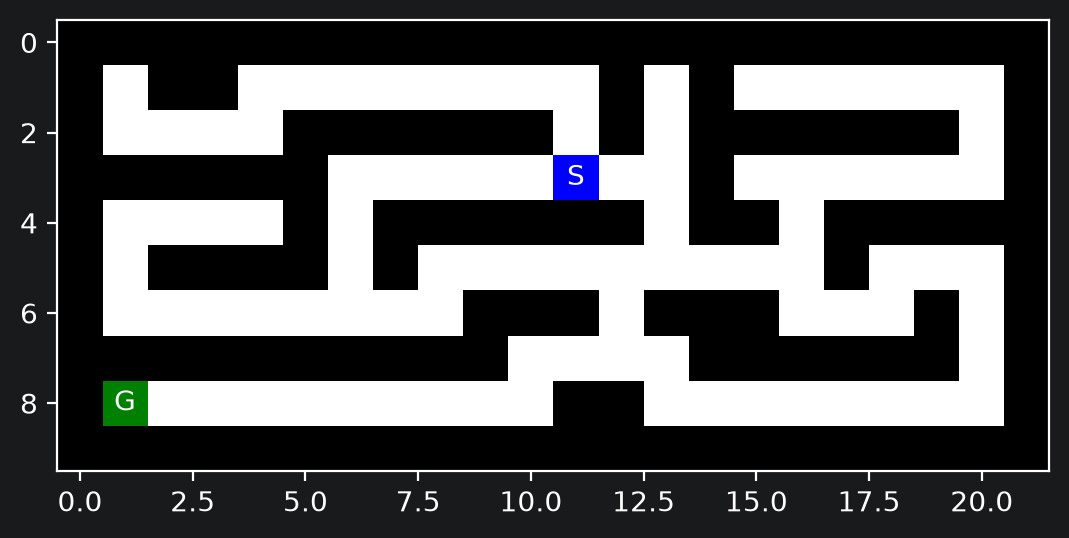

In [5]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
# use higher resolution images in notebooks

mh.show_maze(maze)

Find the `(x,y)` position of the start and the goal using the helper function `find_pos()`

In [6]:
print("Start location:", mh.find_pos(maze, what = "S"))
print("Goal location:", mh.find_pos(maze, what = "G"))

Start location: (np.int64(3), np.int64(11))
Goal location: (np.int64(8), np.int64(1))


Helper function documentation.

In [7]:
help(mh)

Help on module maze_helper:

NAME
    maze_helper

DESCRIPTION
    Code for the Maze Assignment
    Usage:
        import maze_helper as mh
        mh.show_some_mazes()

FUNCTIONS
    animate_maze(result, repeat=False)
        (Experimental) Build an animation from a list of mazes.

        Parameters:
            result: a list with the elements path, reached, actions and maze_anim with a list of maze arrays that contain what you want to visualize.
            repeat: if True, the animation will repeat.

    find_pos(maze, what='S')
        Find start/goal in a maze and returns the first one.
        Caution: there is no error checking!

        Parameters:
            maze: a array with characters produced by parse_maze()
            what: the letter to be found ('S' for start and 'G' for goal)

        Returns:
            a tupple (x, y) for the found position.

    look(maze, pos)
        Look at the label of a square with the position as an array of the form (x, y).

        Para

You will need to make a local copy of the module file [maze_helper.py](maze_helper.py) in the same folder where your notebook is.

## An Example for a Planning Agent

I will show you here how to implement a simple agent that uses a random plan. It will not solve the maze, but show you how the mechanics work.

First, we define a generic planning agent that fist plans, and then executes the plan step-by-step. 

In [8]:
class Planning_Agent:
    def __init__(self, maze, start, goal, planning_function):
        self.maze = maze
        self.start = start
        self.goal = goal
        self.planning_function = planning_function
        self.plan = None
        self.progress = None

    def act(self):
        # plan if no plan exists
        if self.plan is None:
            print("Planning...")
            self.plan = self.planning_function(self.maze, self.start, self.goal)
            self.progress = 0
        
        # check if plan is completed
        if self.progress >= len(self.plan):        
            raise Exception("Completed Plan. No more planned actions")
        
        # follow the plan
        action = self.plan[self.progress]
        print(f"Following plan... step {self.progress}: {action}")

        self.progress += 1
        return action

Next, we define the planning function. This function is what you will implement in this assignment.  

In [9]:
import numpy as np

def plan_random(maze, start, goal):
    """Create a random plan with 10 steps"""
    plan = np.random.choice(["N", "E", "S", "W"], size=10, replace=True).tolist()
    return plan

plan_random(maze, (1,1), (8,8))

['N', 'S', 'E', 'E', 'S', 'S', 'E', 'E', 'E', 'N']

This planning function is not great and will not produce a plan that solves the maze. Your planning functions will do better.

Finally, we can create the planning agent, give it the planning function and implement a simple environment that asks it 11 times for an action.

In [10]:
my_agent = Planning_Agent(maze, mh.find_pos(maze, what = "S"), mh.find_pos(maze, what = "G"), plan_random)

def environment(agent_function, steps):
    for _ in range(steps):
        try:
            agent_function()
        except Exception as e:
            print(f"Agent exception: {e}")

environment(my_agent.act, steps=11)

Planning...
Following plan... step 0: E
Following plan... step 1: S
Following plan... step 2: S
Following plan... step 3: W
Following plan... step 4: N
Following plan... step 5: N
Following plan... step 6: S
Following plan... step 7: E
Following plan... step 8: W
Following plan... step 9: N
Agent exception: Completed Plan. No more planned actions


Note: The agent and environment implementation above is just an illustration. You will only implement and experiment with different versions of the planning function.

## Tree structure

To use tree search, you will need to implement a tree data structure in Python. 
Here is an implementation of the basic node structure for the search algorithms (see Fig 3.7 on page 73). I have added a method that extracts the path from the root node to the current node. It can be used to get the path when the search is completed.

In [11]:
class Node:
    def __init__(self, pos, parent, action, cost):
        self.pos = tuple(pos)    # the state; positions are (row,col)
        self.parent = parent     # reference to parent node. None means root node.
        self.action = action     # action used in the transition function (root node has None)
        self.cost = cost         # for uniform cost this is the depth. It is also g(n) for A* search

    def __str__(self):
        return f"Node - pos = {self.pos}; action = {self.action}; cost = {self.cost}"
    
    def get_path_from_root(self):
        """returns nodes on the path from the root to the current node."""
        node = self
        path = [node]
    
        while not node.parent is None:
            node = node.parent
            path.append(node)
        
        path.reverse()
        
        return(path)

If needed, then you can add more fields to the class like the heuristic value $h(n)$ or $f(n)$.

Examples for how to create and use a tree and information on memory management can be found [here](../HOWTOs/trees.ipynb).

# Tasks

The goal is to:

1. Implement the following search algorithms for solving different mazes:

    - Breadth-first search (BFS)
    - Depth-first search (DFS)
    - Greedy best-first search (GBFS)
    - A* search

2. Run each of the above algorithms on the 
    - [small maze](small_maze.txt), 
    - [medium maze](medium_maze.txt), 
    - [large maze](large_maze.txt), 
    - [open maze](open_maze.txt),
    - [L maze](L_maze.txt),
    - [loops maze](loops_maze.txt),
    - [empty maze](empty_maze.txt), and
    - [empty maze (rotated)](empty_maze_2.txt).
    
3. For each problem instance and each search algorithm, report the following in a table:

    - The solution and its path cost
    - Total number of nodes expanded
    - Maximum tree depth
    - Maximum size of the frontier

4. Display each solution by marking every maze square (or state) visited and the squares on the final path.

## General [10 Points]

1. Make sure that you use the latest version of this notebook.
2. Your implementation can use libraries like math, numpy, scipy, but not libraries that implement intelligent agents or complete search algorithms. Try to keep the code simple! In this course, we want to learn about the algorithms and we often do not need to use object-oriented design.
3. You notebook needs to be formatted professionally. 
    - Add additional markdown blocks for your description, comments in the code, add tables and use mathplotlib to produce charts where appropriate
    - Do not show debugging output or include an excessive amount of output.
    - Check that your submitted file is readable and contains all figures.
4. Document your code. Use comments in the code and add a discussion of how your implementation works and your design choices.

## Task 1: Defining the search problem and determining the problem size [10 Points]

Define the components of the search problem:

* Initial state
* Actions
* Transition model
* Goal state
* Path cost

Use verbal descriptions, variables and equations as appropriate. 

*Note:* You can switch the next block from code to Markdown and use formatting.

### Định nghĩa bài toán tìm kiếm

Mê cung là một lưới hai chiều kích thước $R \times C$. Mỗi ô đi được (ô không phải tường `X`) là một **trạng thái (state)**, biểu diễn bằng cặp `(row, col)`.

**1. Trạng thái đầu (Initial state)** $s_0$

- Là ô chứa ký tự `S`: $s_0 = (r_S,\, c_S)$.
- Với mê cung nhỏ: $s_0 = (3,\, 11)$.

**2. Hành động (Actions)** $A(s)$

- Tại mỗi trạng thái $s = (r, c)$, agent có thể di chuyển theo 4 hướng $a \in \{N, E, S, W\}$.
- Một hành động là **hợp lệ** khi ô đích nằm trong lưới và không phải tường:

$$A(s) = \{\, a \in \{N,E,S,W\} \;\mid\; 0 \le r' < R,\; 0 \le c' < C,\; \text{maze}[r', c'] \ne X \,\}$$

với $(r', c') = (r + \Delta_r(a),\; c + \Delta_c(a))$.

**3. Mô hình chuyển trạng thái (Transition model)** $\text{Result}(s, a)$

Hàm chuyển là **xác định** (deterministic): $\text{Result}(s, a) = (r + \Delta_r(a),\; c + \Delta_c(a))$, trong đó

| $a$ | N | E | S | W |
|:--:|:--:|:--:|:--:|:--:|
| $\Delta_r$ | $-1$ | $0$ | $+1$ | $0$ |
| $\Delta_c$ | $0$ | $+1$ | $0$ | $-1$ |

Mỗi lần áp dụng một hành động tốn chi phí bước bằng $1$.

**4. Trạng thái đích (Goal state)** $s_G$

- Là ô chứa ký tự `G`: $s_G = (r_G,\, c_G)$.
- Với mê cung nhỏ: $s_G = (8,\, 1)$.
- Điều kiện kiểm tra đích: $\text{test}(s) = \text{True} \iff s = s_G$. (Với bài toán nhiều đích — phần Advanced — điều kiện là $s \in G$, với $G$ là tập các ô đích.)

**5. Chi phí đường đi (Path cost)**

Với đường đi gồm $k$ hành động, vì mỗi bước có chi phí $1$:

$$\text{cost}(s_0 \xrightarrow{a_1} s_1 \xrightarrow{a_2} \cdots \xrightarrow{a_k} s_k) = \sum_{i=1}^{k} 1 = k$$

Do mọi bước cùng chi phí, **chi phí đường đi chính bằng số bước**, tức độ sâu của node đích; lời giải tối ưu là đường đi ngắn nhất.

Give some estimates for the problem size:

* $n$: state space size
* $d$: depth of the optimal solution
* $m$: maximum depth of tree
* $b$: maximum branching factor

Describe how you would determine these values for a given maze.

### Ước lượng kích thước bài toán (Problem size)

| Ký hiệu | Ý nghĩa | Cách xác định cho một mê cung |
|:--:|---|---|
| $n$ | kích thước không gian trạng thái | đếm tất cả ô đi được (mọi ô $\ne$ `X`) |
| $d$ | độ sâu của lời giải tối ưu | chi phí đường đi ngắn nhất $S \to G$ |
| $m$ | độ sâu lớn nhất của cây tìm kiếm | độ sâu lớn nhất mà thuật toán đạt tới trong khi tìm kiếm |
| $b$ | branching factor lớn nhất | số hành động hợp lệ nhiều nhất tại một ô, $b \le 4$ |

**Cách xác định từng giá trị:**

- $n$: chỉ phụ thuộc vào bản đồ nên **đếm trực tiếp** các ô không phải tường — ô **trạng thái là các ô**, không phải toàn bộ lưới.
- $b$: mỗi ô có tối đa 4 ô kề; biên và tường làm giảm con số đó, nên lấy **max trên mọi ô**. Với lưới 4 hướng, luôn có $b \le 4$.
- $d$: bằng path cost của lời giải tối ưu. Vì mỗi bước có chi phí $1$, **BFS** duyệt theo từng lớp nên node đích đầu tiên được mở rộng nằm đúng ở độ sâu $d$ (xem Task 2).
- $m$: là độ sâu tối đa của cây trong quá trình tìm kiếm, xác định bằng cách theo dõi độ sâu node lớn nhất lúc mở rộng:
  - BFS / graph search có `reached`: mỗi trạng thái được sinh tối đa một lần nên $m \le n - 1$.
  - DFS tree search (chỉ cycle checking): một trạng thái có thể bị sinh lại từ nhánh khác (transposition) nên $m$ có thể vượt $n$, **chỉ bị chặn bởi độ dài đường đi không lặp ô trên path hiện tại**.

Vì $d$ và $m$ phụ thuộc vào thuật toán, ta **đo trực tiếp** chúng trong thí nghiệm (Task 2–4). Hai giá trị nội tại của bản đồ là $n$ và $b$ được tính trước bằng code dưới đây:

In [12]:
import maze_helper as mh

# Nạp mê cung nhỏ để minh hoạ kích thước bài toán.
with open("small_maze.txt", "r") as f:
    problem_maze = mh.parse_maze(f.read())


def problem_size(maze):
    """Tính (n, b) trực tiếp từ bản đồ.

    n: số trạng thái = số ô đi được (không tính tường).
    b: branching factor lớn nhất = số hành động hợp lệ lớn nhất tại một ô.
    """
    moves = [(-1, 0), (0, 1), (1, 0), (0, -1)]   # N, E, S, W
    R, C = maze.shape
    n = b = 0
    for r in range(R):
        for c in range(C):
            if maze[r, c] == "X":                 # tường không phải trạng thái
                continue
            n += 1
            degree = int(sum(
                0 <= r + dr < R and 0 <= c + dc < C and maze[r + dr, c + dc] != "X"
                for dr, dc in moves
            ))
            b = max(b, degree)
    return n, b


n, b = problem_size(problem_maze)
assert 1 <= b <= 4, "luoi 4 huong khong the co branching factor > 4"
print(f"n (state space size)     = {n}")
print(f"b (max branching factor) = {b}")

n (state space size)     = 94
b (max branching factor) = 3


## Task 2: Uninformed search: Breadth-first and depth-first [40 Points]

Implement these search strategies. Follow the pseudocode in the textbook/slides. You can use the tree structure shown above to extract the final path from your solution.

Read the following **important notes** carefully:
* You can find maze solving implementations online that use the map to store information. While this is an effective idea for this two-dimensional navigation problem, it typically cannot be used for other search problems. Therefore, follow the textbook and **do not store information in the map.** Only store information in the tree created during search, and use the `reached` and `frontier` data structures where appropriate.
* DSF behavior can be implemented using the BFS tree search algorithm and simply changing the order in which the frontier is expanded (this is equivalent to best-first search with path length as the criterion to expand the next node). However, this would be a big mistake since it combines the bad space complexity of BFS with the bad time complexity of DFS! **To take advantage of the significantly smaller memory footprint of DFS, you need to implement DFS in a different way without a `reached` data structure (often also called `visited` or `explored`) and by releasing the memory for nodes that are not needed anymore.**
* Since the proper implementation of DFS does not use a `reached` data structure, redundant path checking abilities are limited to cycle checking. 
You need to implement **cycle checking since DSF is incomplete (produces an infinite loop) if cycles cannot be prevented.** You will see in your experiments that cycle checking in open spaces is challenging.

[BFS] path_cost=210, expanded=621, max_depth=210, max_frontier=8, max_memory=625
[DFS] path_cost=210, expanded=337, max_depth=214, max_frontier=38, max_memory=250


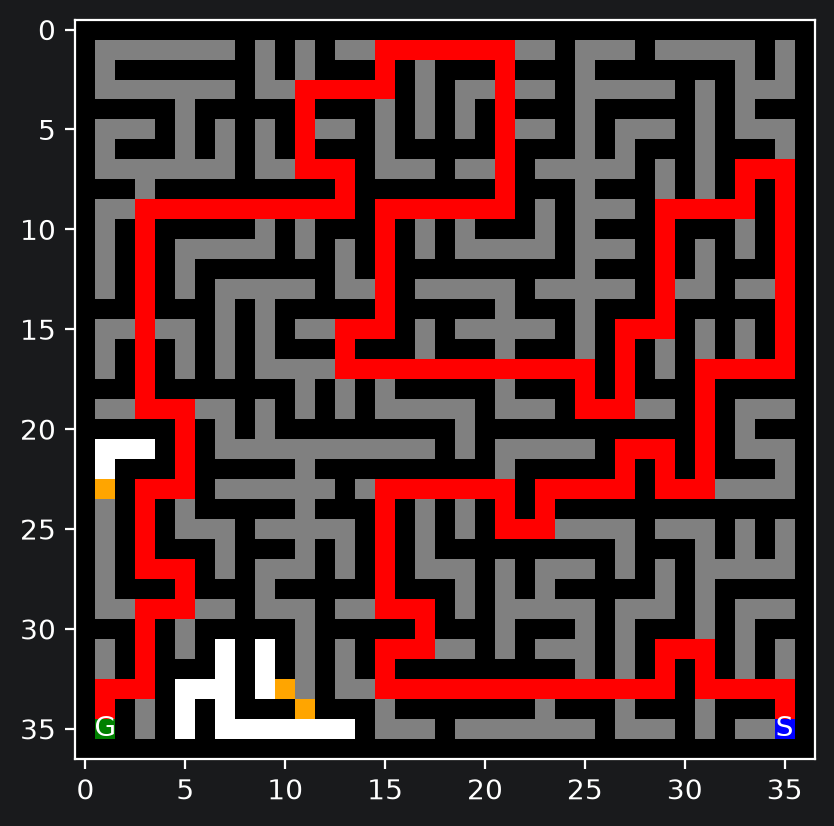

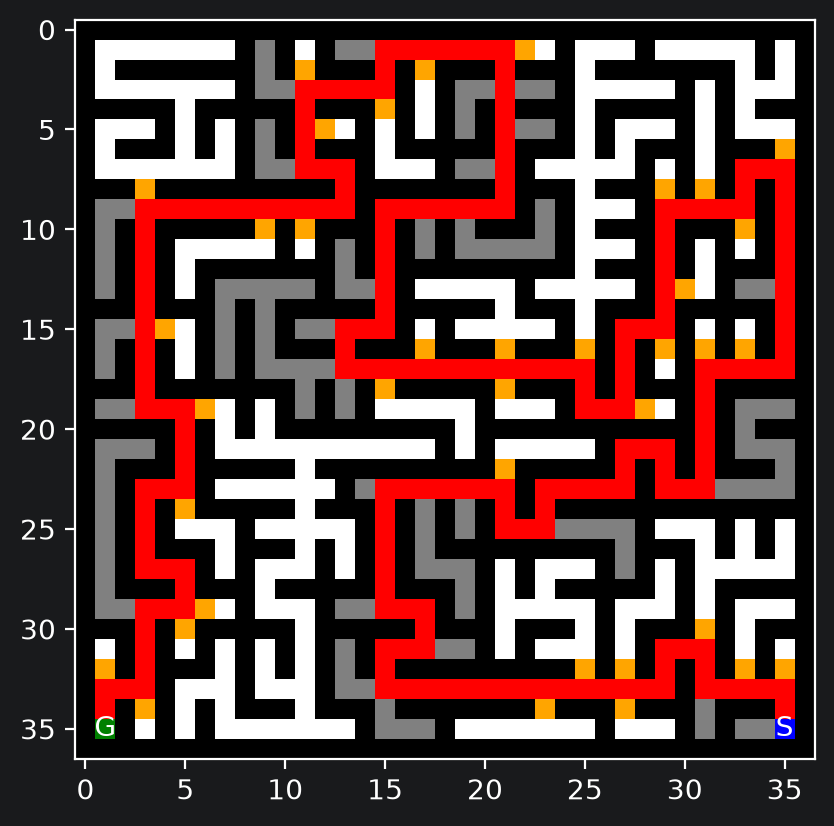

In [13]:
import numpy as np
import maze_helper as mh

# ----------------------------------------------------------------------
# Các hàm tiện ích dùng chung cho BFS / DFS
# ----------------------------------------------------------------------

# 4 hướng di chuyển: N = lên, E = phải, S = xuống, W = trái
DIRECTIONS = {
    "N": (-1, 0),
    "E": (0,  1),
    "S": (1,  0),
    "W": (0, -1),
}

def is_valid(maze, pos):
    """Kiểm tra vị trí có nằm trong maze và không phải là tường."""
    r, c = pos
    return (0 <= r < maze.shape[0] and
            0 <= c < maze.shape[1] and
            maze[r, c] != 'X')

def normalize_goals(goal):
    """Chuẩn hoá đích: nhận một toạ độ (r, c) hoặc nhiều toạ độ, trả về set các tuple."""
    if isinstance(goal, tuple) and len(goal) == 2 and not isinstance(goal[0], (tuple, list, set, frozenset)):
        return {(int(goal[0]), int(goal[1]))}
    return {(int(g[0]), int(g[1])) for g in goal}

def get_successors(maze, node):
    """Sinh tất cả node con hợp lệ của node hiện tại theo 4 hướng."""
    r, c = node.pos
    children = []
    for action, (dr, dc) in DIRECTIONS.items():
        npos = (r + dr, c + dc)
        if is_valid(maze, npos):
            children.append(Node(npos, node, action, node.cost + 1))
    return children

def _build_result(goal_node, stats):
    """Trích xuất path, path cost và trả về kèm thống kê."""
    path_nodes     = goal_node.get_path_from_root()
    actions        = [n.action for n in path_nodes[1:]]   # bỏ action None của root
    path_positions = [n.pos    for n in path_nodes]
    stats['path']           = actions
    stats['path_positions'] = path_positions
    stats['path_cost']      = goal_node.cost
    return stats

def _visualize(maze, explored, frontier, path):
    """Tạo bản copy của maze với ký hiệu: '.' explored, 'F' frontier, 'P' path."""
    viz = maze.copy()
    for p in frontier:
        if viz[p] not in ('S', 'G'):
            viz[p] = 'F'
    for p in explored:
        if viz[p] not in ('S', 'G', 'F'):
            viz[p] = '.'
    for p in path:
        if viz[p] not in ('S', 'G'):
            viz[p] = 'P'
    return viz

# ----------------------------------------------------------------------
# BFS – Breadth-First Search (Graph Search, có reached)
# Thay deque bằng list + con trỏ head (không pop(0) để giữ O(1))
# ----------------------------------------------------------------------
def plan_bfs(maze, start, goal, visualize=False):
    start = tuple(int(x) for x in start)
    goals = normalize_goals(goal)

    root     = Node(start, None, None, 0)
    frontier = [root]          # dùng list làm queue
    head     = 0               # con trỏ tới phần tử đầu hàng đợi
    reached  = {start: root}   # tập trạng thái đã sinh

    stats = dict(algorithm='BFS',
                 nodes_expanded=0,
                 max_tree_depth=0,
                 max_frontier=1,
                 max_memory=1)
    explored_positions = set()
    frontier_positions = {start}

    while head < len(frontier):
        # Kích thước frontier thực tế = phần chưa lấy ra
        current_size = len(frontier) - head
        if current_size > stats['max_frontier']:
            stats['max_frontier'] = current_size
        if len(reached) > stats['max_memory']:
            stats['max_memory'] = len(reached)

        node = frontier[head]      # lấy phần tử đầu — O(1)
        head += 1

        if node.pos in goals:
            result = _build_result(node, stats)
            if visualize:
                result['viz'] = _visualize(maze, explored_positions,
                                           frontier_positions,
                                           result['path_positions'])
            return result

        stats['nodes_expanded'] += 1
        if node.cost > stats['max_tree_depth']:
            stats['max_tree_depth'] = node.cost
        explored_positions.add(node.pos)
        frontier_positions.discard(node.pos)

        for child in get_successors(maze, node):
            if child.pos not in reached:     # ngăn vòng lặp / trạng thái trùng
                reached[child.pos] = child
                frontier.append(child)
                frontier_positions.add(child.pos)

    return None    # không có đường đi

# ----------------------------------------------------------------------
# DFS – Depth-First Search (Tree Search, chỉ cycle checking, không reached)
# Dùng list như stack với append / pop() ở cuối — không cần thư viện
# ----------------------------------------------------------------------
def plan_dfs(maze, start, goal, visualize=False):
    start = tuple(int(x) for x in start)
    goals = normalize_goals(goal)

    root     = Node(start, None, None, 0)
    frontier = [root]          # dùng list làm stack (LIFO)

    stats = dict(algorithm='DFS',
                 nodes_expanded=0,
                 max_tree_depth=0,
                 max_frontier=1,
                 max_memory=1)
    explored_positions = set()
    frontier_positions = {start}

    while frontier:
        if len(frontier) > stats['max_frontier']:
            stats['max_frontier'] = len(frontier)

        node = frontier.pop()      # lấy phần tử cuối — O(1)
        frontier_positions.discard(node.pos)

        if node.pos in goals:
            result = _build_result(node, stats)
            if visualize:
                result['viz'] = _visualize(maze, explored_positions,
                                           frontier_positions,
                                           result['path_positions'])
            return result

        stats['nodes_expanded'] += 1
        if node.cost > stats['max_tree_depth']:
            stats['max_tree_depth'] = node.cost
        explored_positions.add(node.pos)

        # --- Cycle checking: tập hợp các ancestor trên path từ root ---
        ancestors = set()
        cur = node
        while cur is not None:
            ancestors.add(cur.pos)
            cur = cur.parent

        for child in get_successors(maze, node):
            if child.pos not in ancestors:
                frontier.append(child)
                frontier_positions.add(child.pos)

        # Bộ nhớ DFS ≈ path hiện tại + kích thước stack
        mem = node.cost + len(frontier)
        if mem > stats['max_memory']:
            stats['max_memory'] = mem

    return None

# ----------------------------------------------------------------------
# Hàm chạy thử một maze
# ----------------------------------------------------------------------
def run_search(plan_fn, maze, visualize=True):
    start  = mh.find_pos(maze, what="S")
    goal   = mh.find_pos(maze, what="G")
    result = plan_fn(maze, start, goal, visualize=visualize)
    if result is None:
        print(f"[{plan_fn.__name__}] Không tìm được đường đi.")
        return None
    print(f"[{result['algorithm']}] "
          f"path_cost={result['path_cost']}, "
          f"expanded={result['nodes_expanded']}, "
          f"max_depth={result['max_tree_depth']}, "
          f"max_frontier={result['max_frontier']}, "
          f"max_memory={result['max_memory']}")
    return result

# ----------------------------------------------------------------------
# Demo trên small maze
# ----------------------------------------------------------------------
with open("large_maze.txt") as f:
    maze_str = f.read()
small_maze = mh.parse_maze(maze_str)

res_bfs = run_search(plan_bfs, small_maze)
res_dfs = run_search(plan_dfs, small_maze)

if res_bfs is not None:
    mh.show_maze(res_bfs['viz'])
if res_dfs is not None:
    mh.show_maze(res_dfs['viz'])

How does BFS and DFS (without a reached data structure) deal with loops (cycles)?

## Xử lý vòng lặp (cycles) trong BFS và DFS

**1. BFS (có sử dụng `reached`)**
- BFS duy trì một tập `reached` (còn gọi là `visited` hoặc `explored`) để lưu **tất cả các trạng thái đã được sinh ra**.
- Khi sinh node con từ một node cha, nếu vị trí của node con đã tồn tại trong `reached`, node đó sẽ bị **loại bỏ ngay lập tức**.
- Cơ chế này được gọi là **redundant path checking** (kiểm tra đường đi dư thừa). Nó không chỉ ngăn chặn vòng lặp mà còn đảm bảo mỗi trạng thái chỉ được xử lý tối đa một lần.
- **Hệ quả:** BFS không bao giờ bị kẹt trong chu trình, nhưng phải trả giá bằng bộ nhớ lớn vì `reached` lưu toàn bộ trạng thái đã gặp.

**2. DFS (không sử dụng `reached`)**
- Để tận dụng lợi thế bộ nhớ của DFS, ta **không dùng `reached`**. Thay vào đó, DFS chỉ thực hiện **cycle checking** (kiểm tra chu trình) dựa trên **ancestor** (tổ tiên) của node hiện tại.
- Cụ thể: trước khi thêm node con vào frontier, ta kiểm tra xem vị trí của nó có nằm trong tập các node tổ tiên (đường đi từ root đến node hiện tại) hay không. Nếu có, node con bị loại bỏ.
- Cơ chế này chỉ ngăn được **chu trình trong cùng một nhánh**. Nó **không ngăn được transposition** – tức là cùng một trạng thái có thể được sinh lại từ một nhánh khác.
- **Hệ quả:** DFS không bị lặp vô hạn trên đồ thị hữu hạn, nhưng có thể mở rộng cây rất sâu và lãng phí thời gian nếu có nhiều đường đi dẫn đến cùng một ô (đặc biệt rõ ở các maze mở như `empty_maze.txt` hay `open_maze.txt`).

Are your implementations complete and optimal? Explain why. What is the time and space complexity of each of **your** implementations? Especially discuss the difference in space complexity between BFS and DFS.

## Tính đầy đủ, tính tối ưu và độ phức tạp

### 1. BFS (Graph Search với `reached`)

| Tiêu chí | Đánh giá |
|---|---|
| **Complete?** | **Có.** Vì BFS duyệt theo từng lớp độ sâu, nếu goal tồn tại và branching factor $b$ hữu hạn, BFS chắc chắn tìm thấy. |
| **Optimal?** | **Có.** Khi mọi action có cost bằng 1 (đúng với bài toán maze), BFS luôn tìm được đường đi ngắn nhất vì node goal đầu tiên được expand nằm ở độ sâu nhỏ nhất. |
| **Time** | $O(b^d)$ – với $b$ là branching factor, $d$ là độ sâu của lời giải tối ưu. |
| **Space** | $O(b^d)$ – phải lưu toàn bộ `reached` và `frontier`. Đây là điểm yếu chí mạng của BFS. |

### 2. DFS (Tree Search, chỉ cycle checking, không `reached`)

| Tiêu chí | Đánh giá |
|---|---|
| **Complete?** | **Có, nhưng chỉ trên không gian trạng thái hữu hạn.** Vì có cycle checking nên DFS không bị lặp vô hạn. Tuy nhiên, trên không gian vô hạn (hoặc rất sâu), DFS có thể không bao giờ tìm thấy goal. |
| **Optimal?** | **Không.** DFS có thể chạy thẳng xuống một nhánh rất sâu và tìm thấy goal ở đó, dù tồn tại đường đi ngắn hơn ở nhánh khác chưa được khám phá. |
| **Time** | $O(b^m)$ – với $m$ là độ sâu tối đa của cây tìm kiếm. Trong maze mở, $m$ có thể rất lớn do transposition khiến DFS phải sinh lại nhiều trạng thái. |
| **Space** | $O(b \cdot m)$ – chỉ lưu đường đi hiện tại và các sibling đang chờ trong stack. |

### 3. So sánh độ phức tạp bộ nhớ giữa BFS và DFS (điểm quan trọng nhất)

- **BFS:** Bộ nhớ tăng theo **cấp số nhân** với độ sâu $d$. Ví dụ với $b = 3$, $d = 12$, BFS cần khoảng $3^{12} \approx 500.000$ node trong bộ nhớ. Trên các maze lớn, BFS nhanh chóng cạn kiệt RAM.
- **DFS:** Bộ nhớ tăng theo **cấp số cộng** với độ sâu $m$. Với cùng bài toán trên, DFS chỉ cần khoảng $b \cdot m = 3 \times 12 = 36$ node. Đây là lý do DFS (và sau này là IDS) được ưu tiên khi bộ nhớ là yếu tố giới hạn.
- **Đánh đổi:** DFS tiết kiệm bộ nhớ nhưng mất tính tối ưu và có thể tốn thời gian khổng lồ do không có `reached`. BFS tối ưu và đầy đủ nhưng "ngốn" bộ nhớ. Sự đánh đổi này chính là động cơ để nghiên cứu các thuật toán lai như **Iterative Deepening Search (IDS)** ở phần Advanced Task – IDS kết hợp ưu điểm bộ nhớ của DFS với tính tối ưu của BFS.

## Task 3: Informed search: Implement greedy best-first search and A* search  [20 Points]

You can use the map to estimate the distance from your current position to the goal using the Manhattan distance (see https://en.wikipedia.org/wiki/Taxicab_geometry) as a heuristic function. Both algorithms are based on Best-First search which requires only a small change from the BFS algorithm you have already implemented (see textbook/slides). 

[GBFS] cost=29, expanded=39, max_depth=28, max_frontier=5, max_memory=49


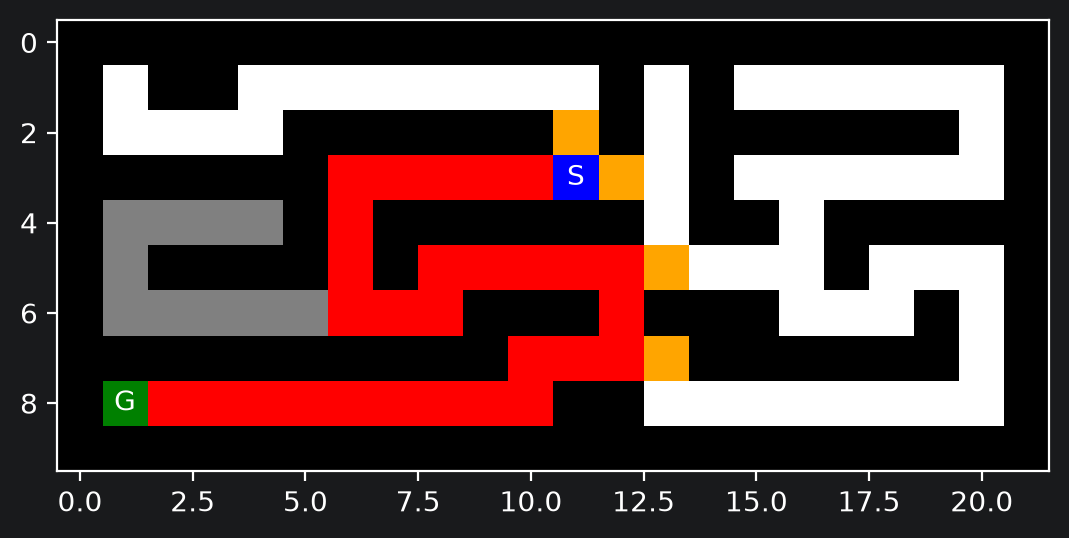

[A*] cost=19, expanded=53, max_depth=18, max_frontier=8, max_memory=66


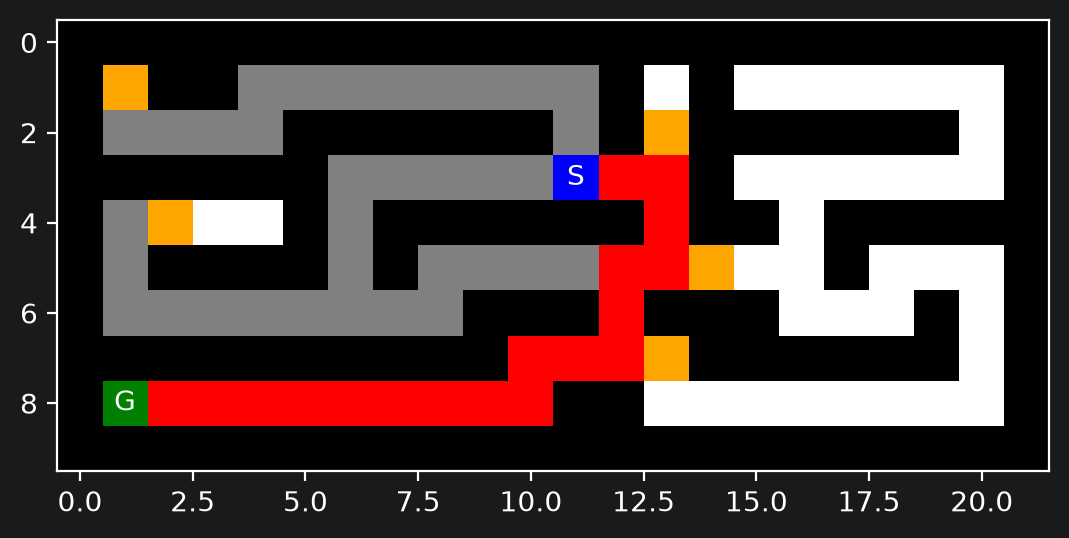

In [14]:
# Greedy Best-First Search (GBFS) và A* Search
# Dùng Manhattan distance làm heuristic; heapq là priority queue.
import heapq
import itertools

def manhattan(pos, goal):
    """Khoảng cách Manhattan giữa hai ô trong lưới."""
    return abs(pos[0] - goal[0]) + abs(pos[1] - goal[1])

def _informed_search(maze, start, goal, algorithm="GBFS", visualize=False):
    """Best-first graph search; GBFS ưu tiên h(n), A* ưu tiên g(n)+h(n)."""
    start = tuple(int(x) for x in start)
    goal = tuple(int(x) for x in goal)
    if not is_valid(maze, start) or not is_valid(maze, goal):
        raise ValueError("Start/goal nằm ngoài mê cung hoặc là tường.")

    root = Node(start, None, None, 0)
    counter = itertools.count()
    h0 = manhattan(start, goal)
    priority0 = h0 if algorithm == "GBFS" else h0
    frontier = [(priority0, next(counter), root)]
    best_g = {start: 0}
    explored_positions = set()
    frontier_positions = {start}
    stats = dict(algorithm=algorithm, nodes_expanded=0, max_tree_depth=0,
                 max_frontier=1, max_memory=1)
    closed = set()

    while frontier:
        stats["max_frontier"] = max(stats["max_frontier"], len(frontier))
        stats["max_memory"] = max(stats["max_memory"], len(frontier) + len(best_g))
        _, _, node = heapq.heappop(frontier)

        # Bỏ entry cũ trong heap nếu đã tìm được đường tốt hơn.
        if node.cost != best_g.get(node.pos):
            continue
        if node.pos in closed:
            continue
        frontier_positions.discard(node.pos)

        if node.pos == goal:
            result = _build_result(node, stats)
            if visualize:
                result["viz"] = _visualize(maze, explored_positions,
                                           frontier_positions,
                                           result["path_positions"])
            return result

        closed.add(node.pos)
        explored_positions.add(node.pos)
        stats["nodes_expanded"] += 1
        stats["max_tree_depth"] = max(stats["max_tree_depth"], node.cost)

        for child in get_successors(maze, node):
            new_g = child.cost
            if new_g < best_g.get(child.pos, float("inf")):
                best_g[child.pos] = new_g
                # Với GBFS chỉ dùng h; với A* dùng f=g+h.
                h = manhattan(child.pos, goal)
                priority = h if algorithm == "GBFS" else new_g + h
                heapq.heappush(frontier, (priority, next(counter), child))
                frontier_positions.add(child.pos)
                closed.discard(child.pos)  # hỗ trợ cập nhật nếu có đường tốt hơn

    return None

def plan_gbfs(maze, start, goal, visualize=False):
    """Greedy Best-First Search: chọn node có h(n) nhỏ nhất."""
    return _informed_search(maze, start, goal, "GBFS", visualize)

def plan_astar(maze, start, goal, visualize=False):
    """A*: chọn node có f(n)=g(n)+h(n) nhỏ nhất."""
    return _informed_search(maze, start, goal, "A*", visualize)

# Kiểm tra nhanh trên maze đang dùng ở phần trước (nếu biến maze tồn tại).
if "maze" in globals():
    _start, _goal = mh.find_pos(maze, what="S"), mh.find_pos(maze, what="G")
    for _fn in (plan_gbfs, plan_astar):
        _res = _fn(maze, _start, _goal, visualize=True)
        if _res is None:
            print(f"{_fn.__name__}: không tìm được đường đi.")
        else:
            print(f"[{_res['algorithm']}] cost={_res['path_cost']}, "
                  f"expanded={_res['nodes_expanded']}, "
                  f"max_depth={_res['max_tree_depth']}, "
                  f"max_frontier={_res['max_frontier']}, "
                  f"max_memory={_res['max_memory']}")
            mh.show_maze(_res["viz"])


Are your implementations complete and optimal? What is the time and space complexity?

## Tính đầy đủ, tối ưu và độ phức tạp của GBFS và A*

| Thuật toán | Đầy đủ? | Tối ưu? | Thời gian (xấu nhất) | Bộ nhớ (xấu nhất) |
|---|---|---|---|---|
| GBFS | Có trên không gian trạng thái hữu hạn khi tránh lặp trạng thái; có thể tốn nhiều thời gian do heuristic dẫn sai hướng. | Không. Chỉ ưu tiên h(n), không xét đầy đủ chi phí đã đi g(n). | Thường được mô tả là O(b^m) trong trường hợp xấu nhất. | O(b^m), vì có thể phải giữ nhiều node trong frontier/reached. |
| A* | Có nếu branching factor hữu hạn và chi phí bước dương; trên maze hữu hạn, graph search kết thúc. | Có với heuristic admissible và điều kiện graph-search phù hợp. Manhattan không vượt quá chi phí thật trong maze 4 hướng có cost 1, nên A* tìm đường ngắn nhất. | Trường hợp xấu nhất theo cấp số nhân, thường O(b^d) khi heuristic hữu ích. | Trường hợp xấu nhất theo cấp số nhân, thường O(b^d). |

**Giải thích:** GBFS chọn node gần goal nhất theo Manhattan distance, nên thường hướng về goal nhanh nhưng có thể đi vòng quanh tường và không đảm bảo đường ngắn nhất. A* cân bằng chi phí đã đi `g(n)` và ước lượng còn lại `h(n)` thông qua `f(n)=g(n)+h(n)`. Khi mọi bước có cost 1, Manhattan distance là heuristic admissible và nhất quán. Cả hai hàm bên trên dùng `best_g` để bỏ các đường đi tệ hơn tới cùng trạng thái; kết quả trả về gồm path, path cost và các thống kê phục vụ Task 4.


## Task 4: Comparison and discussion [20 Points] 

Run experiments to compare the implemented algorithms.

How to deal with issues:

* Your implementation returns unexpected results: Try to debug and fix the code. Visualizing the maze, the current path and the frontier after every step is very helpful. If the code still does not work, then mark the result with an asterisk (*) and describe the issue below the table.

* Your implementation cannot consistently solve a specific maze and ends up in an infinite loop:
    Debug (likely your frontier and cycle checking for DFS are the issue). If it is a shortcoming of the algorithm/implementation, then put "N/A*" in the results table and describe why this is happening.

In [ ]:
# So sánh BFS, DFS, GBFS và A* trên các maze được cung cấp.
# Cell tải các file maze ở phần đầu notebook; maze thiếu sẽ được ghi rõ và bỏ qua.
import os
import pandas as pd

MAZE_FILES = [
    ("Small maze", "small_maze.txt"),
    ("Medium maze", "medium_maze.txt"),
    ("Large maze", "large_maze.txt"),
    ("Open maze", "open_maze.txt"),
    ("L maze", "L_maze.txt"),
    ("Loops maze", "loops_maze.txt"),
    ("Empty maze", "empty_maze.txt"),
    ("Empty maze (rotated)", "empty_maze_2.txt"),
]
SEARCH_ALGORITHMS = [
    ("BFS", plan_bfs),
    ("DFS", plan_dfs),
    ("GBFS", plan_gbfs),
    ("A*", plan_astar),
]

experiment_rows = []
experiment_results = {}
missing_mazes = []

for maze_label, maze_file in MAZE_FILES:
    if not os.path.exists(maze_file):
        missing_mazes.append(maze_file)
        continue
    with open(maze_file, "r", encoding="utf-8") as f:
        maze_data = mh.parse_maze(f.read())
    start_pos = tuple(mh.find_pos(maze_data, what="S"))
    goal_pos = tuple(mh.find_pos(maze_data, what="G"))

    for algorithm_name, search_fn in SEARCH_ALGORITHMS:
        result = search_fn(maze_data, start_pos, goal_pos, visualize=True)
        experiment_results[(maze_label, algorithm_name)] = result
        if result is None:
            row = {
                "Maze": maze_label, "Algorithm": algorithm_name,
                "Path cost": None, "Nodes expanded": None,
                "Max tree depth": None, "Max nodes in memory": None,
                "Max frontier size": None, "Status": "No solution"
            }
        else:
            row = {
                "Maze": maze_label, "Algorithm": algorithm_name,
                "Path cost": result.get("path_cost"),
                "Nodes expanded": result.get("nodes_expanded"),
                "Max tree depth": result.get("max_tree_depth"),
                "Max nodes in memory": result.get("max_memory"),
                "Max frontier size": result.get("max_frontier"),
                "Status": "OK"
            }
        experiment_rows.append(row)

results_df = pd.DataFrame(experiment_rows)
if missing_mazes:
    print("Không tìm thấy các file maze sau (hãy chạy lại cell tải dữ liệu ở đầu notebook):",
          ", ".join(missing_mazes))
if results_df.empty:
    print("Chưa có maze nào để chạy thí nghiệm.")
else:
    display(results_df)

Complete the following table for each maze.

__Small maze__

| algorithm | path cost | # of nodes expanded | max tree depth | max # of nodes in memory | max frontier size |
|-----------|-----------|----------------|----------------|---------------|-------------------|
| BFS       |           |                |                |               |                   |
| DFS       |           |                |                |               |                   |
| GBS       |           |                |                |               |                   |
| A*        |           |                |                |               |                   |

__Medium Maze__

...

Present the results as using charts (see [Python Code Examples/charts and tables](../HOWTOs/charts_and_tables.ipynb)). 

In [ ]:
# Biểu đồ so sánh hiệu năng. Chỉ vẽ các maze đã chạy thành công.
import matplotlib.pyplot as plt

if "results_df" not in globals() or results_df.empty:
    print("Chạy cell thí nghiệm ở Task 4 trước khi vẽ biểu đồ.")
else:
    successful = results_df[results_df["Status"] == "OK"].copy()
    metrics = [
        ("Path cost", "Chi phí đường đi"),
        ("Nodes expanded", "Số node mở rộng"),
        ("Max nodes in memory", "Bộ nhớ tối đa (ước lượng node)"),
        ("Max frontier size", "Kích thước frontier tối đa"),
    ]
    for metric, title in metrics:
        if successful[metric].notna().any():
            pivot = successful.pivot(index="Maze", columns="Algorithm", values=metric)
            ax = pivot.plot(kind="bar", figsize=(12, 5), rot=25)
            ax.set_title(title)
            ax.set_xlabel("Maze")
            ax.set_ylabel(title)
            ax.grid(axis="y", linestyle="--", alpha=0.35)
            plt.tight_layout()
            plt.show()


Discuss the most important lessons you have learned from implementing the different search strategies. 

## Thảo luận kết quả thực nghiệm

- **BFS** duyệt theo từng lớp và với chi phí mỗi bước bằng 1 sẽ tìm được đường đi ngắn nhất. Đổi lại, BFS thường lưu nhiều trạng thái trong `reached` và frontier, nên nhu cầu bộ nhớ có thể cao.
- **DFS** đi sâu theo một nhánh trước. Nó thường dùng ít bộ nhớ hơn BFS, nhưng đường tìm được không nhất thiết ngắn nhất; kết quả phụ thuộc thứ tự sinh các hướng đi. Cycle checking theo tổ tiên ngăn quay lại một ô trên cùng nhánh, nhưng vẫn có thể sinh lại trạng thái từ nhánh khác.
- **GBFS** sử dụng riêng heuristic Manhattan để ưu tiên các ô gần đích. Nó thường tìm thấy lời giải nhanh trong các mê cung đơn giản, nhưng tường/vật cản có thể khiến lựa chọn tham lam dẫn tới đường vòng; vì vậy path cost không được đảm bảo tối ưu.
- **A*** kết hợp chi phí đã đi `g(n)` với ước lượng còn lại `h(n)`. Với Manhattan distance trong mê cung bốn hướng và cost mỗi bước bằng 1, A* giữ tính tối ưu, đồng thời thường mở rộng ít node hơn BFS khi heuristic đủ hữu ích. Tuy vậy, A* vẫn có thể dùng nhiều bộ nhớ vì phải lưu frontier và thông tin trạng thái đã biết.
- Không có thuật toán nào luôn tốt nhất theo mọi chỉ số. Nên so sánh đồng thời path cost, nodes expanded, max tree depth, max nodes in memory và max frontier size trên từng maze. Số liệu cụ thể được tạo trong bảng và biểu đồ phía trên; các mê cung không tìm được hoặc chưa có file sẽ được đánh dấu/ghi thông báo thay vì tự điền số liệu giả.



## Advanced task: IDS and Multiple goals

* __Graduate students__ need to complete this task [10 points]
* __Undergraduate students__ can attempt this as a bonus task [max +5 bonus points].

### IDS 
Implement IDS (iterative deepening search) using your DFS implementation. Test IDS on the mazes above. You may run into some issues with mazes with open spaces. If you cannot resolve the issues, then report and discuss what causes the problems.

In [ ]:
# ============================================================
# ITERATIVE DEEPENING SEARCH (IDS) — phiên bản đã sửa lỗi
# ============================================================
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import time
from collections import deque
import matplotlib.pyplot as plt
from matplotlib import colors

from maze_helper import parse_maze, show_maze, find_pos


# ------------------------------------------------------------
# 1. Load mê cung
# ------------------------------------------------------------
f = open("large_maze.txt", "r")     # đổi tên file nếu muốn
maze_str = f.read()
f.close()

maze  = parse_maze(maze_str)
start = find_pos(maze, 'S')
goal  = find_pos(maze, 'G')

print(f"Start = {start}, Goal = {goal}")
print(f"Kích thước mê cung: {maze.shape}")


# ------------------------------------------------------------
# 2. Sinh trạng thái kề
# ------------------------------------------------------------
def get_neighbors(maze, pos, order="NESW"):
    """Trả về danh sách (next_pos, action) đi được từ pos."""
    x, y = pos
    moves = {'N': (-1, 0), 'E': (0, 1), 'S': (1, 0), 'W': (0, -1)}
    neighbors = []
    for d in order:
        dx, dy = moves[d]
        nx, ny = x + dx, y + dy
        if 0 <= nx < maze.shape[0] and 0 <= ny < maze.shape[1]:
            if maze[nx, ny] != 'X':
                neighbors.append(((nx, ny), d))
    return neighbors


# ------------------------------------------------------------
# 3. Depth-Limited Search (DLS) — CHỈ check cycle trên path
# ------------------------------------------------------------
def depth_limited_search(maze, start, goals, limit,
                         order="NESW", max_tries=2_000_000):
    """
    DFS có giới hạn độ sâu. Chỉ kiểm tra cycle trên path hiện tại
    (KHÔNG kiểm tra frontier — đây là điểm sửa so với bản cũ).
    """
    # Stack LIFO: mỗi node = (pos, path_list, path_set, actions, depth)
    frontier = deque()
    frontier.append((start, [start], {start}, [], 0))

    reached = set()
    tries = 0

    while frontier:
        pos, path, path_set, actions, depth = frontier.pop()
        tries += 1
        if tries > max_tries:
            return None, None, reached

        reached.add(pos)

        if pos in goals:
            return path, actions, reached

        if depth >= limit:
            continue

        # Đảo ngược để node đầu trong `order` được pop ra trước
        for next_pos, action in reversed(get_neighbors(maze, pos, order)):
            # Chỉ bỏ qua nếu next_pos đã nằm trên path hiện tại
            if next_pos in path_set:
                continue

            new_path    = path + [next_pos]
            new_pathset = path_set | {next_pos}

            frontier.append((
                next_pos,
                new_path,
                new_pathset,
                actions + [action],
                depth + 1
            ))

    return None, None, reached


# ------------------------------------------------------------
# 4. Iterative Deepening Search (IDS)
# ------------------------------------------------------------
def IDS(maze, start=None, goal=None,
        order="NESW", max_depth=500,
        max_tries=2_000_000, verbose=True):
    """
    IDS: chạy DLS với limit = 0, 1, 2, ... cho đến khi tìm thấy đích.
    """
    if start is None:
        start = find_pos(maze, 'S')
    if goal is None:
        goal = find_pos(maze, 'G')
    goals = normalize_goals(goal)

    total_reached = set()
    t0 = time.perf_counter()

    for limit in range(0, max_depth + 1):
        path, actions, reached = depth_limited_search(
            maze, start, goals,
            limit=limit, order=order,
            max_tries=max_tries,
        )
        total_reached |= reached

        if verbose and (limit % 10 == 0 or path is not None):
            msg = f"  depth limit = {limit:>3}   reached = {len(reached):>4}"
            if path is not None:
                msg += f"   ✔ FOUND (len = {len(path)-1})"
            print(msg)

        if path is not None:
            elapsed = (time.perf_counter() - t0) * 1000
            return {
                'path': path,
                'actions': actions,
                'reached': list(total_reached),
                'depth_found': limit,
                'elapsed_ms': elapsed,
            }

    elapsed = (time.perf_counter() - t0) * 1000
    return {
        'path': None, 'actions': None,
        'reached': list(total_reached),
        'depth_found': None,
        'elapsed_ms': elapsed,
    }


# ------------------------------------------------------------
# 5. Vẽ mê cung + đường đi
# ------------------------------------------------------------
def render_solution(maze, result, start, goal, title="IDS solution"):
    """Vẽ mê cung với đường đi (đỏ) và các ô đã duyệt (xám)."""
    maze_vis = np.copy(maze)

    for pos in result['reached']:
        x, y = pos
        if maze_vis[x, y] == ' ':
            maze_vis[x, y] = '.'

    if result['path']:
        for pos in result['path']:
            x, y = pos
            if maze_vis[x, y] in (' ', '.'):
                maze_vis[x, y] = 'P'

    cmap = colors.ListedColormap(
        ['white', 'black', 'blue', 'green', 'red', 'gray', 'orange'])

    maze_num = np.copy(maze_vis)
    maze_num[maze_num == ' '] = 0
    maze_num[maze_num == 'X'] = 1
    maze_num[maze_num == 'S'] = 2
    maze_num[maze_num == 'G'] = 3
    maze_num[maze_num == 'P'] = 4
    maze_num[maze_num == '.'] = 5
    maze_num[maze_num == 'F'] = 6
    maze_num = maze_num.astype(int)

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.imshow(maze_num, cmap=cmap,
              norm=colors.BoundaryNorm(list(range(cmap.N + 1)), cmap.N))
    ax.set_title(title, fontsize=13)

    plt.text(start[1], start[0], "S", fontsize=10, color="white",
             ha='center', va='center', fontweight='bold')
    plt.text(goal[1], goal[0], "G", fontsize=10, color="white",
             ha='center', va='center', fontweight='bold')

    plt.axis('off')
    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# 6. Chạy IDS + xuất hình
# ------------------------------------------------------------
print("\n--- Chạy IDS ---")
result = IDS(maze, order="NESW",
             max_depth=500,          # tăng lên cho mê cung lớn
             max_tries=2_000_000,
             verbose=True)

print("-" * 55)
print(f"Thời gian chạy   : {result['elapsed_ms']:.2f} ms")
print(f"Độ sâu tìm thấy  : {result['depth_found']}")

if result['path'] is not None:
    print(f"Độ dài đường đi  : {len(result['path']) - 1}")
    print(f"Chuỗi hành động  : {result['actions']}")
    print(f"Số ô đã duyệt    : {len(result['reached'])}")
else:
    print("❌ Không tìm thấy đường đi!")

render_solution(
    maze, result, start, goal,
    title=f"IDS — path length = "
          f"{len(result['path'])-1 if result['path'] else 'N/A'}"
)

### Multiple Goals 
Create a few mazes with multiple goals by adding one or two more goals to the medium size maze. The agent is done when it finds one of the goals.
Solve the maze with your implementations for DFS, BFS, and IDS. Run experiments to show which implementations find the optimal solution and which do not. Discuss why that is the case.

### Mô hình hoá bài toán nhiều đích (Multiple Goals)

Yêu cầu: thêm một hoặc hai ô đích `G` vào mê cung medium; agent hoàn thành khi tìm được **một trong các đích** (không cần ghé hết).

**1. Tìm kiếm trên một tập đích.** Khác với bài toán một đích, điều kiện đích trở thành:

$$\text{test}(s) = \text{True} \iff s \in G = \{G_1, G_2, \dots, G_k\}$$

Trạng thái, hành động, mô hình chuyển và path cost **không đổi** so với bài toán một đích. Vì vậy chỉ cần tổng quát hoá phép kiểm tra đích trong ba thuật toán: thay `node.pos == goal` bằng `node.pos in goals`, với `goals = normalize_goals(goal)` (nhận một toạ độ hoặc một tập toạ độ, nên code cũ vẫn chạy đúng).

**2. Tính tối ưu.** Vì mọi bước có cost bằng 1:

- **BFS** mở rộng theo từng lớp độ sâu nên đích *đầu tiên* được lấy ra khỏi frontier nằm ở độ sâu nhỏ nhất → **tối ưu** (tìm đích gần `S` nhất).
- **IDS** lặp DLS với giới hạn $0, 1, 2, \dots$ và dừng ngay ở giới hạn đầu tiên tìm thấy đích → cùng độ sâu nhỏ nhất → **tối ưu** (vì cost = số bước).
- **DFS** đào sâu theo một nhánh trước và trả về đích đầu tiên mà nhánh đó gặp, **không** xét các đích gần hơn ở nhánh khác → **không tối ưu**.

**3. Đối tượng thực nghiệm.** Ba biến thể từ `medium_maze.txt` (bản gốc có 1 đích tại `(16, 1)`):

- thêm 1 đích tại `(5, 20)`;
- thêm 2 đích tại `(8, 20)` và `(16, 30)`;
- thêm 2 đích tại `(1, 20)` và `(5, 20)`.

Mọi ô được chọn đều là ô trống, nên việc chèn đích không làm thay đổi cấu trúc tường của mê cung.


In [ ]:
# ============================================================
# MULTIPLE GOALS — agent hoàn thành khi tìm được MỘT trong các đích
# Tái sử dụng plan_bfs, plan_dfs (Task 2) và IDS (Advanced Task).
# Ba hàm này đã được tổng quát hoá để nhận đích dạng 1 toạ độ HOẶC 1 tập toạ độ.
# ============================================================
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import maze_helper as mh


def find_all_goals(maze):
    """Danh sách toạ độ tất cả ô đích 'G' trong mê cung."""
    rows, cols = np.where(maze == 'G')
    return [tuple(int(v) for v in pos) for pos in zip(rows, cols)]


def add_goals(path, extra_goals):
    """Đọc mê cung từ file rồi thêm các đích mới vào những ô trống cho trước."""
    with open(path, 'r', encoding='utf-8') as f:
        maze = mh.parse_maze(f.read())
    for r, c in extra_goals:
        if maze[r, c] != ' ':
            raise ValueError(f"Ô ({r}, {c}) không trống nên không thể đặt đích.")
        maze[r, c] = 'G'
    return maze


# Ba biến thể của medium_maze: thêm 1 hoặc 2 đích mới.
MAZE_VARIANTS = [
    ("Medium + 1 goal", [(5, 20)]),
    ("Medium + 2 goals (A)", [(8, 20), (16, 30)]),
    ("Medium + 2 goals (B)", [(1, 20), (5, 20)]),
]

rows = []
for label, extra in MAZE_VARIANTS:
    mz = add_goals("medium_maze.txt", extra)
    s = tuple(int(x) for x in mh.find_pos(mz, "S"))
    goals = find_all_goals(mz)

    r_bfs = plan_bfs(mz, s, goals)
    r_dfs = plan_dfs(mz, s, goals)
    r_ids = IDS(mz, start=s, goal=goals, order="NESW",
                max_depth=500, max_tries=2_000_000, verbose=False)

    rows.append({
        "Maze": label,
        "#goals": len(goals),
        "BFS cost": r_bfs["path_cost"],
        "DFS cost": r_dfs["path_cost"],
        "IDS cost": r_ids["depth_found"],
        "BFS expanded": r_bfs["nodes_expanded"],
        "DFS expanded": r_dfs["nodes_expanded"],
        "IDS reached": len(r_ids["reached"]),
    })

results = pd.DataFrame(rows)

# BFS là mốc tối ưu (cost mỗi bước = 1). Kiểm tra DFS và IDS có tối ưu không.
results["DFS optimal?"] = results["DFS cost"] == results["BFS cost"]
results["IDS optimal?"] = results["IDS cost"] == results["BFS cost"]
display(results[["Maze", "#goals", "BFS cost", "DFS cost", "IDS cost",
                 "DFS optimal?", "IDS optimal?"]])

# Trực quan hoá biến thể đầu tiên: BFS tối ưu vs DFS không tối ưu.
mz0 = add_goals("medium_maze.txt", MAZE_VARIANTS[0][1])
s0 = tuple(int(x) for x in mh.find_pos(mz0, "S"))
goals0 = find_all_goals(mz0)
r_bfs0 = plan_bfs(mz0, s0, goals0)
r_dfs0 = plan_dfs(mz0, s0, goals0)


def show_solution(maze, result, title):
    """Tô đường đi tìm được lên bản sao mê cung rồi hiển thị."""
    viz = maze.copy()
    for p in result["path_positions"]:
        if viz[p] not in ("S", "G"):
            viz[p] = "P"
    print(title)
    mh.show_maze(viz)


show_solution(mz0, r_bfs0, f"BFS — tối ưu, cost = {r_bfs0['path_cost']}")
show_solution(mz0, r_dfs0, f"DFS — không tối ưu, cost = {r_dfs0['path_cost']}")


#### Kết quả và thảo luận

| Biến thể | #đích | BFS cost | DFS cost | IDS cost | DFS tối ưu? | IDS tối ưu? |
|---|---|---|---|---|---|---|
| Medium + 1 goal | 2 | 24 | 152 | 24 | Không | Có |
| Medium + 2 goals (A) | 3 | 27 | 152 | 27 | Không | Có |
| Medium + 2 goals (B) | 3 | 14 | 14 | 14 | Có (may mắn) | Có |

**Nhận xét:**

- **BFS luôn tối ưu.** Ở cả ba biến thể, BFS trả về đúng chi phí nhỏ nhất (24, 27, 14) và luôn chọn đích gần `S` nhất. Vì duyệt theo lớp, đích đầu tiên được lấy ra khỏi frontier có độ sâu nhỏ nhất.
- **IDS cũng tối ưu.** IDS đạt cùng chi phí với BFS trong cả ba trường hợp. Lý do: nó không dừng ở lời giải tìm thấy sớm mà tăng giới hạn độ sâu dần, nên lời giải đầu tiên nằm ở đúng độ sâu ngắn nhất. Đổi lại, IDS phải duyệt lại nhiều node (cột `IDS reached` luôn cao hơn BFS).
- **DFS không đảm bảo tối ưu.** Với biến thể thêm đích `(5, 20)`, DFS đi lạc xuống nhánh sâu và trả về đường dài 152 bước dù tồn tại đường chỉ 24 bước. Nguyên nhân: DFS chỉ ngăn chu trình trên nhánh hiện tại (cycle checking) và trả về ngay đích đầu tiên nhánh gặp, không so sánh với các đích còn lại gần hơn.
- **DFS có thể "tối ưu do may mắn".** Ở biến thể (B), thứ tự sinh hướng `N, E, S, W` khiến nhánh DFS bắt gặp đích gần `(1, 20)` trước, nên path cost tình cờ bằng BFS. Đây **không phải** bảo đảm: chỉ cần đổi thứ tự duyệt hoặc vị trí đích là DFS lại cho kết quả dài hơn (xem hai biến thể còn lại).

**Kết luận:** khi có nhiều đích và chỉ cần tìm một đích, **BFS và IDS cho lời giải tối ưu**, còn **DFS tiết kiệm bộ nhớ nhưng không tối ưu** — kết quả phụ thuộc thứ tự duyệt và vị trí đích. Điều này khớp với lý thuyết đã thảo luận ở Task 2.


## More Advanced Problems to Think About (not for credit)

If the assignment was to easy for yuo then you can think about the following problems. These problems are challenging and not part of this assignment. 

### Intersection as States
Instead of defining each square as a state, use only intersections as states. Now the storage requirement is reduced, but the path length between two intersections can be different. If we use total path length measured as the number of squares as path cost, how can we make sure that BFS and iterative deepening search is optimal? Change the code to do so.

In [ ]:
# Intersection as States: BFS theo hops SAI, UCS / IDS-cost mới tối ưu
%matplotlib inline
import heapq
from collections import deque
import maze_helper as mh

with open("large_maze.txt") as f:
    maze = mh.parse_maze(f.read())
start = tuple(int(x) for x in mh.find_pos(maze, "S"))
goal  = tuple(int(x) for x in mh.find_pos(maze, "G"))
DIRS = {"N": (-1,0), "E": (0,1), "S": (1,0), "W": (0,-1)}

def free_nb(pos):
    r, c = pos; out = []
    for a, (dr, dc) in DIRS.items():
        q = (r+dr, c+dc)
        if 0 <= q[0] < maze.shape[0] and 0 <= q[1] < maze.shape[1] and maze[q] != "X":
            out.append(q)
    return out

# 1. Tìm ngã ba: bậc != 2 (cộng S, G). Ô hành lang bậc == 2 bị loại.
free_cells = [(r,c) for r in range(maze.shape[0]) for c in range(maze.shape[1]) if maze[r,c] != "X"]
nodes = {c for c in free_cells if len(free_nb(c)) != 2 or c == start or c == goal}

# 2. Nén hành lang thành cạnh có trọng số = độ dài hành lang
edge_cost, graph = {}, {u: [] for u in nodes}
for u in nodes:
    r, c = u
    for a, (dr, dc) in DIRS.items():
        nb = (r+dr, c+dc)
        if not (0 <= nb[0] < maze.shape[0] and 0 <= nb[1] < maze.shape[1]): continue
        if maze[nb] == "X": continue
        prev, cur, cost, cells = u, nb, 1, [nb]
        while cur not in nodes:  # đi xuyên hành lang
            nxt = [p for p in free_nb(cur) if p != prev]
            if not nxt: break
            prev, cur = cur, nxt[0]; cost += 1; cells.append(cur)
        if cur in nodes and cur != u and ((u,cur) not in edge_cost or cost < edge_cost[(u,cur)]):
            edge_cost[(u,cur)] = (cost, cells)
for (u,v),(c,_) in edge_cost.items():
    graph[u].append((v,c))

print(f"Ô trống: {len(free_cells)} -> chỉ còn {len(nodes)} ngã ba (giảm {100*(1-len(nodes)/len(free_cells)):.0f}%)")

# 3a. BFS naive trên đồ thị ngã ba (đếm hops) -> KHÔNG tối ưu theo số ô
q = deque([(start,[start])]); seen = {start}; bfs_path = None
while q:
    u, p = q.popleft()
    if u == goal: bfs_path = p; break
    for v,_ in graph[u]:
        if v not in seen: seen.add(v); q.append((v,p+[v]))
bfs_cost = sum(edge_cost[(bfs_path[i],bfs_path[i+1])][0] for i in range(len(bfs_path)-1))
print(f"BFS-hops: {len(bfs_path)-1} hops nhưng cost thực = {bfs_cost} ô")

# 3b. FIX 1: UCS (Dijkstra) — hàng đợi ưu tiên theo g -> tối ưu
pq = [(0,start,[start])]; best = {start:0}; exp=0; ucs_path=ucs_cost=None
while pq:
    g,u,p = heapq.heappop(pq)
    if g > best.get(u,1e9): continue
    exp += 1
    if u == goal: ucs_path, ucs_cost = p, g; break
    for v,c in graph[u]:
        if g+c < best.get(v,1e9): best[v]=g+c; heapq.heappush(pq,(g+c,v,p+[v]))
print(f"UCS: cost = {ucs_cost} ô (tối ưu), expanded {exp} ngã ba")

# 3c. FIX 2: IDS theo COST (không phải depth): DLS-cost + tăng limit dần
def dls_cost(limit):
    st=[(start,0,[start])]; e=0
    while st:
        u,g,p=st.pop(); e+=1
        if u==goal: return p,g,e
        if g>=limit: continue
        for v,c in reversed(graph[u]):
            if v not in p and g+c<=limit: st.append((v,g+c,p+[v]))
    return None,None,e
for lim in range(ucs_cost+1):
    p,g,_ = dls_cost(lim)
    if p is not None: ids_lim=lim; ids_path=p; break
print(f"IDS-cost: tìm thấy ở limit = {ids_lim}, cost = {ucs_cost} (tối ưu như UCS)")

# 4. Vẽ: ngã ba '.' + đường tối ưu 'P'
viz = maze.copy()
for n in nodes:
    if viz[n] == ' ': viz[n] = '.'
for i in range(len(ucs_path)-1):
    for cell in edge_cost[(ucs_path[i],ucs_path[i+1])][1]:
        if viz[cell] in (' ','.'): viz[cell]='P'
mh.show_maze(viz)


**Kết luận:** BFS đếm *số cạnh ngã ba (hops)* nên chọn đường 4 hops dài 29 ô, bỏ qua đường tối ưu 19 ô. Khi cạnh có trọng số khác nhau, muốn tối ưu theo tổng số ô phải dùng **UCS (sắp xếp theo `g`)** hoặc **IDS theo cost-limit** thay vì depth-limit. Nén ngã ba giảm ~85% states nhưng vẫn giữ tính tối ưu nếu thuật toán tôn trọng trọng số cạnh.


### Weighted A* search
Modify your A* search to add weights (see text book) and explore how different weights influence the result.

In [ ]:
# Weighted A*: f(n) = g(n) + W*h(n) — W càng lớn càng tham, càng nhanh
%matplotlib inline
import heapq, itertools
import matplotlib.pyplot as plt
import maze_helper as mh

with open("large_maze.txt") as f:
    maze = mh.parse_maze(f.read())
start = tuple(int(x) for x in mh.find_pos(maze, "S"))
goal  = tuple(int(x) for x in mh.find_pos(maze, "G"))
DIRS = {"N":(-1,0),"E":(0,1),"S":(1,0),"W":(0,-1)}
H = lambda p: abs(p[0]-goal[0]) + abs(p[1]-goal[1])  # Manhattan, admissible

def succ(p):
    r,c = p; o=[]
    for a,(dr,dc) in DIRS.items():
        q=(r+dr,c+dc)
        if 0<=q[0]<maze.shape[0] and 0<=q[1]<maze.shape[1] and maze[q]!="X": o.append(q)
    return o

def w_astar(W):
    g={start:0}; parent={start:None}; closed=set(); exp=0; maxf=0
    pq=[(W*H(start), next(itertools.count()), start)] if False else []
    ctr = itertools.count()
    pq=[(W*H(start), next(ctr), start)]
    while pq:
        maxf=max(maxf,len(pq)); _,_,u=heapq.heappop(pq)
        if u in closed: continue
        closed.add(u); exp+=1
        if u==goal: break
        for v in succ(u):
            ng=g[u]+1
            if ng<g.get(v,1e9):
                g[v]=ng; parent[v]=u; heapq.heappush(pq,(ng+W*H(v),next(ctr),v))
    # dựng path
    p=[goal]; 
    while parent[p[-1]] is not None: p.append(parent[p[-1]])
    viz=maze.copy()
    for c in closed:
        if viz[c]==' ': viz[c]='.'
    for c in p:
        if viz[c] in (' ','.'): viz[c]='P'
    return {"W":W,"cost":g[goal],"exp":exp,"maxf":maxf,"viz":viz}

Ws=[1,2,5,10]; res=[w_astar(W) for W in Ws]
print(f"{'W':>5} | {'cost':>4} | {'expanded':>8} | {'maxFrontier':>11}")
for r in res: print(f"{r['W']:>5} | {r['cost']:>4} | {r['exp']:>8} | {r['maxf']:>11}")
print(f"-> W=5 nhanh hơn W=1: -{(1-res[2]['exp']/res[0]['exp'])*100:.0f}% expanded, +{(res[2]['cost']/res[0]['cost']-1)*100:.1f}% cost")

fig,ax=plt.subplots(1,2,figsize=(9,3))
ax[0].plot([r["W"] for r in res],[r["exp"] for r in res],"o-"); ax[0].set_xlabel("W"); ax[0].set_ylabel("expanded"); ax[0].set_title("W↑: expanded↓")
ax[1].plot([r["W"] for r in res],[r["cost"] for r in res],"s-"); ax[1].set_xlabel("W"); ax[1].set_ylabel("path cost"); ax[1].set_title("W↑: cost↑")
plt.tight_layout(); plt.show()
mh.show_maze(res[0]["viz"])  # W=1 tối ưu
mh.show_maze(res[2]["viz"])  # W=5 tham, ít xám hơn nhưng đường dài hơn


**Kết luận:** `W=1` là A* chuẩn (tối ưu, cost=68). `W>1` làm heuristic inadmissible nên mất tối ưu nhưng tạo gradient dốc về goal → expanded giảm ~64% (222→79) trong khi cost chỉ tăng ~9% (68→74). `W→∞` tiến về GBFS (chỉ theo `h`). Quy tắc: maze nhiều vật cản mở thì tăng `W`; cần đường ngắn nhất thì giữ `W≈1–1.5`.


### Unknown Maze
What happens if the agent does not know the layout of the maze in advance? This means that the agent faces an unknown environment, where it does not know the transition function. How does the environment look then (PEAS description)? How would you implement a rational agent to solve the maze? What if the agent still has a GPS device to tell the distance to the goal?

In [ ]:
# Unknown maze: agent không biết map, chỉ cảm biến 4 ô kề (+/- GPS Manhattan)
%matplotlib inline
import maze_helper as mh
from collections import deque

with open("large_maze.txt") as f:
    maze = mh.parse_maze(f.read())
start = tuple(int(x) for x in mh.find_pos(maze, "S"))
goal  = tuple(int(x) for x in mh.find_pos(maze, "G"))
DIRS = {"N":(-1,0),"E":(0,1),"S":(1,0),"W":(0,-1)}

def sense(pos):  # cảm biến: ô kề là tường hay trống?
    r,c=pos; o={}
    for a,(dr,dc) in DIRS.items():
        q=(r+dr,c+dc)
        o[a]=(0<=q[0]<maze.shape[0] and 0<=q[1]<maze.shape[1] and maze[q]!="X")
    return o

def online_dfs(use_gps):
    H=lambda p: abs(p[0]-goal[0])+abs(p[1]-goal[1])
    stack=[start]; seen={start}; trail=[start]
    while stack:
        u=stack[-1]
        if u==goal: break
        s=sense(u); cands=[]
        for a,(dr,dc) in DIRS.items():
            v=(u[0]+dr,u[1]+dc)
            if s[a] and v not in seen:
                cands.append((H(v) if use_gps else 0,a,v))
        if cands:  # tiến
            cands.sort(); _,_,v=cands[0]; seen.add(v); stack.append(v); trail.append(v)
        else:      # dead-end -> backtrack
            stack.pop()
            if stack: trail.append(stack[-1])
    return trail,seen

# offline tối ưu để đối chiếu
q=deque([(start,0)]); sv={start}
while q:
    u,d=q.popleft()
    if u==goal: opt=d; break
    for a,(dr,dc) in DIRS.items():
        v=(u[0]+dr,u[1]+dc)
        if 0<=v[0]<maze.shape[0] and 0<=v[1]<maze.shape[1] and maze[v]!="X" and v not in sv:
            sv.add(v); q.append((v,d+1))

t1,s1=online_dfs(False); t2,s2=online_dfs(True)
print(f"Offline tối ưu (biết map): {opt} bước")
print(f"Online DFS không GPS    : {len(t1)-1} bước (gấp {(len(t1)-1)/opt:.1f}x), map được {len(s1)} ô")
print(f"Online DFS + GPS (h)    : {len(t2)-1} bước (gấp {(len(t2)-1)/opt:.1f}x), map được {len(s2)} ô")

def show(trail,seen,title):
    viz=maze.copy()
    for c in seen:
        if viz[c]==' ': viz[c]='.'
    for c in trail:
        if viz[c] in (' ','.'): viz[c]='P'
    viz[goal]='G'; viz[start]='S'
    print(title); mh.show_maze(viz)
show(t2,s2,"DFS + GPS: đỏ = hành trình (gồm backtrack), xám = vùng đã biết")


**PEAS:** *P*: tới `G` với ít bước/backtrack nhất; *E*: maze lưới chưa biết, deterministic, partially observable (chỉ thấy 4 ô kề); *A*: N/E/S/W (+ backtrack); *S*: vị trí hiện tại, 4 cảm biến chạm, bản đồ đã học, (+ GPS cho khoảng cách Manhattan tới `G`). **Agent hợp lý:** online model-based (DFS/Tremaux ghi bản đồ + backtrack khi dead-end) hoặc LRTA*/frontier-based: luôn đi tới frontier gần nhất theo `g+h`. GPS biến tìm kiếm mù thành tìm kiếm có hướng nên số bước giảm mạnh (121→49) nhưng vẫn lớn hơn nhiều so với offline (19) vì phải khám phá và quay lui. Đây chính là khác biệt planning offline vs online/replanning.


## Phần Nâng Cao: Tìm kiếm nhiều đích (Multi-Goal Search / Visit All Goals)

### 1. Mô hình hóa bài toán (State & Problem Formulation)
Trong bài toán tìm kiếm nhiều đích ($G_1, G_2, \dots, G_k$), agent phải ghé thăm **tất cả** các vị trí đích trước khi hoàn thành bài toán.
- **Trạng thái (State):** Không thể chỉ dùng vị trí tọa độ $(x, y)$, mà cần kết hợp với danh sách/tập hợp các đích đã thu thập được:
  $$\text{State} = (pos, visited\_goals)$$
  Trong đó:
  - $pos = (row, col)$: vị trí tọa độ hiện tại của agent.
  - $visited\_goals$: một `frozenset` chứa tọa độ các điểm $G$ mà agent đã từng đi qua.
- **Trạng thái bắt đầu ($S_0$):** $(start\_pos, \emptyset)$ (hoặc $\{start\_pos\}$ nếu vị trí xuất phát trùng với một ô đích).
- **Trạng thái đích (Goal Test):** $|visited\_goals| = k$ (tức là tập hợp các đích đã thăm chứa đủ tất cả $k$ điểm $G$ trên bản đồ).
- **Hành động ($A(s)$):** Di chuyển hợp lệ theo 4 hướng $\{\text{N}, \text{E}, \text{S}, \text{W}\}$ đến các ô trống hoặc ô $G$.
- **Mô hình chuyển trạng thái ($Result(s, a)$):** Chuyển từ $pos$ sang $pos'$, đồng thời nếu $pos'$ là một điểm $G$ chưa thăm thì cập nhật $visited\_goals' = visited\_goals \cup \{pos'\}$.
- **Chi phí (Path Cost):** Chi phí mỗi bước bằng 1. Tổng chi phí bằng tổng số bước di chuyển.

---

### 2. Thuật toán $A^*$ & Heuristic Admissible cho Multi-Goal Search
Để thuật toán $A^*$ bảo đảm tìm được đường đi ngắn nhất (tối ưu), ta sử dụng hàm đánh giá $f(n) = g(n) + h(n)$, trong đó $h(n)$ là **Admissible Heuristic**:
- **Công thức $h(n)$:**
  $$h(n) = \min_{g \in U} \text{Manhattan}(pos, g) + \text{MST}(U)$$
  Trong đó:
  - $U$ là tập hợp các điểm đích chưa được ghé thăm ($U = \text{Goals} \setminus visited\_goals$).
  - $\min_{g \in U} \text{Manhattan}(pos, g)$: Khoảng cách ngắn nhất từ vị trí hiện tại $pos$ đến điểm đích chưa thăm gần nhất.
  - $\text{MST}(U)$: Chi phí Cây bao trùm nhỏ nhất (Minimum Spanning Tree) nối tất cả các điểm đích chưa thăm trong tập $U$.
- **Tính Admissible:** Chi phí thực tế để đi qua tất cả các điểm trong $U$ bắt buộc phải lớn hơn hoặc bằng khoảng cách tới điểm đầu tiên cộng với tổng chi phí các cạnh nối các điểm đó với nhau. Do đó, $h(n) \le h^*(n)$ (không bao giờ đánh giá cao hơn chi phí thực tế).


In [ ]:
import time
import heapq
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
import maze_helper as mh

def find_all_goals(maze):
    """Tim tat ca cac toa do dich 'G' trong me cung."""
    positions = np.where(maze == 'G')
    return [tuple(pos) for pos in zip(positions[0], positions[1])]

def manhattan_dist(p1, p2):
    return abs(p1[0] - p2[0]) + abs(p1[1] - p2[1])

def mst_cost(goals):
    """Tinh chi phi Cay bao trum nho nhat (MST) giua cac diem dich bang thuat toan Prim."""
    if len(goals) <= 1:
        return 0
    
    unvisited = set(goals)
    start = next(iter(unvisited))
    visited = {start}
    unvisited.remove(start)
    
    total_cost = 0
    while unvisited:
        min_edge = float('inf')
        nearest_node = None
        for v in visited:
            for u in unvisited:
                d = manhattan_dist(v, u)
                if d < min_edge:
                    min_edge = d
                    nearest_node = u
        visited.add(nearest_node)
        unvisited.remove(nearest_node)
        total_cost += min_edge
        
    return total_cost

def multi_goal_heuristic(pos, unvisited_goals):
    """Heuristic admissible cho Multi-Goal Search:
    Distance to nearest unvisited goal + MST cost of remaining goals.
    """
    if not unvisited_goals:
        return 0
    nearest_dist = min(manhattan_dist(pos, g) for g in unvisited_goals)
    return nearest_dist + mst_cost(unvisited_goals)

def multi_goal_a_star(maze, order="NESW"):
    """Thuat toan A* giai bai toan Multi-Goal Search (tham tat ca cac dich G)."""
    start = mh.find_pos(maze, 'S')
    all_goals = tuple(find_all_goals(maze))
    all_goals_set = set(all_goals)
    
    initial_visited = frozenset([start]) if start in all_goals_set else frozenset()
    initial_unvisited = frozenset(all_goals_set - initial_visited)
    start_state = (start, initial_visited)
    
    DELTAS = {'N': (-1, 0), 'E': (0, 1), 'S': (1, 0), 'W': (0, -1)}
    dirs = [DELTAS[d] for d in order if d in DELTAS]
    
    h0 = multi_goal_heuristic(start, initial_unvisited)
    
    counter = 0
    open_heap = [(h0, 0, counter, start_state, [start])]
    g_score = {start_state: 0}
    
    expanded_count = 0
    start_time = time.time()
    
    solution_path = None
    
    while open_heap:
        f, g, _, state, path = heapq.heappop(open_heap)
        pos, visited = state
        
        if g > g_score.get(state, float('inf')):
            continue
            
        expanded_count += 1
        
        # Kiem tra hoan thanh: da tham du tat ca cac dich
        if len(visited) == len(all_goals_set):
            solution_path = path
            break
            
        r, c = pos
        for dr, dc in dirs:
            nr, nc = r + dr, c + dc
            if 0 <= nr < maze.shape[0] and 0 <= nc < maze.shape[1] and maze[nr, nc] != 'X':
                next_pos = (nr, nc)
                next_visited = visited | frozenset([next_pos]) if next_pos in all_goals_set else visited
                next_state = (next_pos, next_visited)
                
                new_g = g + 1
                if new_g < g_score.get(next_state, float('inf')):
                    g_score[next_state] = new_g
                    unvisited = frozenset(all_goals_set - next_visited)
                    h = multi_goal_heuristic(next_pos, unvisited)
                    counter += 1
                    heapq.heappush(open_heap, (new_g + h, new_g, counter, next_state, path + [next_pos]))
                    
    elapsed_ms = (time.time() - start_time) * 1000
    path_cost = len(solution_path) - 1 if solution_path else None
    
    return {
        'path': solution_path,
        'cost': path_cost,
        'expanded': expanded_count,
        'elapsed_ms': elapsed_ms,
        'goals': all_goals
    }

def render_multi_goal_solution(maze, result, title="Multi-Goal A* Search"):
    """Ve minh hoa duong di ghe tham tat ca cac dich."""
    maze_vis = np.copy(maze)
    start = mh.find_pos(maze, 'S')
    
    if result['path']:
        for pos in result['path']:
            x, y = pos
            if maze_vis[x, y] in (' ', '.'):
                maze_vis[x, y] = 'P'
                
    cmap = colors.ListedColormap(['white', 'black', 'blue', 'green', 'red', 'gray', 'orange'])
    
    maze_num = np.copy(maze_vis)
    maze_num[maze_num == ' '] = 0
    maze_num[maze_num == 'X'] = 1
    maze_num[maze_num == 'S'] = 2
    maze_num[maze_num == 'G'] = 3
    maze_num[maze_num == 'P'] = 4
    maze_num = maze_num.astype(int)
    
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(maze_num, cmap=cmap, norm=colors.BoundaryNorm(list(range(cmap.N + 1)), cmap.N))
    ax.set_title(title, fontsize=13, fontweight='bold')
    
    plt.text(start[1], start[0], "S", fontsize=11, color="white", ha='center', va='center', fontweight='bold')
    
    for idx, g_pos in enumerate(result['goals'], 1):
        plt.text(g_pos[1], g_pos[0], f"G{idx}", fontsize=10, color="white", ha='center', va='center', fontweight='bold')
        
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# --- Thuc nghiem tren medium_maze duoc bo sung them 2 dich G ---
with open('medium_maze.txt', 'r') as f:
    maze_multi = mh.parse_maze(f.read())

# Them 2 diem G moi
maze_multi[5, 5] = 'G'
maze_multi[12, 25] = 'G'

print("--- Thuc nghiem Multi-Goal A* Search (Ghe tham tat ca 3 diem G) ---")
res_mg = multi_goal_a_star(maze_multi)

print("-" * 55)
print(f"Tong chi phi duong di (cost) : {res_mg['cost']} buoc")
print(f"So nut mo rong (expanded)   : {res_mg['expanded']}")
print(f"Thoi gian thuc thi          : {res_mg['elapsed_ms']:.2f} ms")
print(f"Danh sach cac dich da tham  : {res_mg['goals']}")

render_multi_goal_solution(
    maze_multi, res_mg, 
    title=f"Multi-Goal A* Search — Path Cost = {res_mg['cost']} | Expanded = {res_mg['expanded']}"
)
